<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [2]</a>'.</span>

# Winter Storm Uri: Impact Analysis

On February 15–20, 2021, Winter Storm Uri knocked out generation across Texas, pushing wholesale prices to ERCOT's $9,000/MWh cap. This notebook simulates what happened to real customers across different contract types (fixed, variable, indexed) using actual Pecan Street consumption data and real Power to Choose plans from October 2019.

Comparison to recent period (June 2026) shows how markets have stabilized post-Uri.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

from txpower.ercot_prices import load_spp_annual_xlsx, synthetic_uri_spp, find_ercot_2021_file
from txpower.cost_engine import simulate_month
from txpower.models import Contract, RateType, TduCharges

class blogstyle:
    PALETTE = ["#2A6F7E", "#FF3F86", "#7281C2", "#FFA175", "#00BAAC", "#484848"]
    @staticmethod
    def title(ax, title, subtitle=""):
        ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=12, fontweight="bold")
    @staticmethod
    def save(fig, name):
        pass

print("✓ Imports complete")

✓ Imports complete


<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [2]:
ptc_csv = ROOT / "data/raw/ptc_offers_20191001.csv"
plans_df = pd.read_csv(ptc_csv)
print(f"Loaded {len(plans_df)} plans from Oct 2019 Power to Choose")
print(f"\nRate type breakdown:")
print(plans_df["[RateType]"].value_counts())

Loaded 1915 plans from Oct 2019 Power to Choose

Rate type breakdown:
[RateType]
Fixed       1710
Variable     194
Indexed       10
Name: count, dtype: int64


In [3]:
raw_dir = ROOT / "data" / "raw"
ps_files_feb2021 = list(raw_dir.glob("*pecan*2021*"))
ps_csv = ps_files_feb2021[0] if ps_files_feb2021 else raw_dir / "pecan_street_15min_austin.csv"
data_period = "Feb 2021" if ps_files_feb2021 else "2018 (as proxy)"

ps_df = pd.read_csv(ps_csv, usecols=["dataid", "local_15min", "grid"])
ps_df["local_15min"] = pd.to_datetime(ps_df["local_15min"], utc=True).dt.tz_convert("America/Chicago")

print(f"Loaded {len(ps_df)} consumption records ({data_period})")
print(f"Unique homes: {ps_df['dataid'].nunique()}")
print(f"Date range: {ps_df['local_15min'].min()} to {ps_df['local_15min'].max()}")

Loaded 873286 consumption records (2018 (as proxy))
Unique homes: 25
Date range: 2018-01-01 00:00:00-06:00 to 2018-12-31 23:45:00-06:00


In [4]:
spp_real = None
data_source = None

ercot_file = find_ercot_2021_file()
if ercot_file:
    try:
        spp_real = load_spp_annual_xlsx(ercot_file, settlement_point="LZ_NORTH")
        data_source = f"ERCOT 2021 SPP xlsx ({ercot_file.name})"
        print(f"✓ Loaded real ERCOT SPP: {len(spp_real)} records")
    except Exception as e:
        print(f"⚠ Could not load ERCOT xlsx: {e}")
        spp_real = None

spp_synthetic = synthetic_uri_spp()
if spp_real is None:
    print(f"ℹ Using synthetic Uri prices for full Feb 1-28")
    data_source = "Synthetic SPP (documented Uri scenario)"
else:
    print(f"✓ Data source: {data_source}")

print(f"✓ Loaded synthetic Uri prices: {len(spp_synthetic)} records (Feb 1-28, fallback)")

✓ Loaded real ERCOT SPP: 35036 records
✓ Data source: ERCOT 2021 SPP xlsx (rpt.00013061.0000000000000000.RTMLZHBSPP_2021.xlsx)
✓ Loaded synthetic Uri prices: 2688 records (Feb 1-28, fallback)


In [5]:
home_groups = ps_df.groupby("dataid")["grid"].sum().sort_values(ascending=False)
net_consumer_homes = home_groups[home_groups > 0].index.tolist()
sample_homes = sorted(net_consumer_homes)

print(f"Found {len(sample_homes)} net-consumer homes (ALL available in Pecan Street dataset)")
print(f"\nHome consumption summary:")
for home_id in sample_homes[:5]:
    total = ps_df[ps_df["dataid"] == home_id]["grid"].sum()
    print(f"  Home {home_id}: {total:.0f} kWh")
print(f"  ... ({len(sample_homes) - 5} more homes)")

Found 24 net-consumer homes (ALL available in Pecan Street dataset)

Home consumption summary:
  Home 661: 21146 kWh
  Home 1642: 23464 kWh
  Home 2335: 18607 kWh
  Home 2361: 13859 kWh
  Home 2818: 23428 kWh
  ... (19 more homes)


In [6]:
def get_feb_2021_usage(home_id: int) -> pd.Series:
    home_data = ps_df[ps_df["dataid"] == home_id].copy()
    
    if home_data.empty:
        return None
    
    feb_data = home_data[
        (home_data["local_15min"].dt.month == 2) &
        (home_data["local_15min"].dt.year == 2021)
    ].copy()
    
    if feb_data.empty:
        feb_data = home_data[
            (home_data["local_15min"].dt.month == 3) &
            (home_data["local_15min"].dt.year == 2018)
        ].copy()
        data_note = "March 2018 proxy"
    else:
        data_note = "Real Feb 2021"
    
    if feb_data.empty:
        return None
    
    feb_data["kwh"] = feb_data["grid"] * (15 / 60)
    feb_data = feb_data.set_index("local_15min").sort_index()
    usage = feb_data["kwh"].resample("h").sum()
    
    naive_index = usage.index.tz_localize(None)
    if data_note == "March 2018 proxy":
        feb_index = pd.to_datetime(
            naive_index.strftime('%Y-02-01')
        ) + pd.to_timedelta(naive_index.day - 1, unit='D')
        feb_index = feb_index.map(lambda x: x.replace(year=2021))
    else:
        feb_index = naive_index.map(lambda x: x.replace(year=2021))
    
    usage.index = feb_index.tz_localize("America/Chicago", ambiguous=True, nonexistent='shift_forward')
    usage.attrs['data_source'] = data_note
    
    return usage

usages = {}
data_sources = {}
for home_id in sample_homes:
    usage = get_feb_2021_usage(home_id)
    if usage is not None:
        usages[home_id] = usage
        data_sources[home_id] = usage.attrs.get('data_source', 'unknown')

print(f"Prepared usage data for {len(usages)} homes")
print(f"Usage index tz: {list(usages.values())[0].index.tz}")

Prepared usage data for 24 homes
Usage index tz: America/Chicago


In [7]:
def ptc_row_to_contract(row) -> Contract:
    rate_type_map = {"Fixed": RateType.FIXED, "Variable": RateType.VARIABLE, "Indexed": RateType.INDEXED}
    
    return Contract(
        rep_name=row["[RepCompany]"],
        plan_name=row["[Product]"],
        rate_type=rate_type_map.get(row["[RateType]"], RateType.FIXED),
        term_months=int(row["[TermValue]"]) if pd.notna(row["[TermValue]"]) else 12,
        energy_charge_per_kwh=float(row["[kwh1000]"]),
        base_monthly_charge=0.0,
        tdu=TduCharges("Oncor", 4.23, 0.038),
        indexed_adder_per_kwh=0.010 if rate_type_map.get(row["[RateType]"]) == RateType.INDEXED else None,
        avg_price_500=float(row["[kwh500]"]) if pd.notna(row["[kwh500]"]) else None,
        avg_price_1000=float(row["[kwh1000]"]),
        avg_price_2000=float(row["[kwh2000]"]) if pd.notna(row["[kwh2000]"]) else None,
        efl_source_file="Wayback Oct 1, 2019",
    )

np.random.seed(42)
contracts = []
for _, row in plans_df.iterrows():
    contracts.append(ptc_row_to_contract(row))

print(f"Created {len(contracts)} Contract objects")
print(f"\nBreakdown:")
for rt in [RateType.FIXED, RateType.VARIABLE, RateType.INDEXED]:
    count = sum(1 for c in contracts if c.rate_type == rt)
    pct = 100 * count / len(contracts)
    print(f"  {rt.value}: {count} ({pct:.1f}%)")

Created 1915 Contract objects

Breakdown:
  fixed: 1711 (89.3%)
  variable: 194 (10.1%)
  indexed: 10 (0.5%)


In [8]:
spp = (spp_real if spp_real is not None else spp_synthetic).copy()

if spp_real is not None:
    if spp.index.has_duplicates:
        spp = spp[~spp.index.duplicated(keep='first')]
else:
    spp.index = pd.DatetimeIndex([
        x.replace(year=2021).tz_localize(None) if x.tz else x.replace(year=2021)
        for x in spp.index
    ])
    spp.index = spp.index.tz_localize("America/Chicago", ambiguous=True, nonexistent='shift_forward')

print(f"SPP date range: {spp.index.min()} to {spp.index.max()}")
print(f"SPP price range: ${spp.min():.4f} to ${spp.max():.2f}/kWh")

results = []
for home_id, usage in usages.items():
    price_aligned = spp.reindex(usage.index, method="ffill")
    
    for contract in contracts:
        try:
            bill = simulate_month(
                usage,
                contract,
                spp_per_kwh=price_aligned if contract.rate_type == RateType.INDEXED else None
            )
            
            results.append({
                "home_id": home_id,
                "rep": contract.rep_name,
                "plan": contract.plan_name,
                "rate_type": contract.rate_type.value,
                "total_kwh": bill["total_kwh"],
                "total_bill": bill["total"],
                "effective_rate_c_kwh": bill["effective_per_kwh"] * 100,
            })
        except Exception as e:
            pass

results_df = pd.DataFrame(results)
results_df = results_df[results_df["total_bill"] > 0].reset_index(drop=True)
print(f"\n✓ Simulated {len(results_df)} bills (net-importer homes only)")
print(results_df.head())

SPP date range: 2021-01-01 00:00:00-06:00 to 2021-12-31 23:45:00-06:00
SPP price range: $-0.0317 to $9.31/kWh



✓ Simulated 32559 bills (net-importer homes only)
   home_id           rep                                               plan  \
0      661  TEXPO ENERGY                     Texpo's Savings AutoPay E-Plan   
1      661  TEXPO ENERGY  Texpo's Clear Blue Skies 100% Renewable Fixed ...   
2      661    TXU ENERGY                                       Flex Forward   
3      661           YEP         Your Energy Plan Fixed Rate Autopay E-Plan   
4      661           YEP             No Long Term Commitment AutoPay E-Plan   

  rate_type  total_kwh  total_bill  effective_rate_c_kwh  
0     fixed    -18.061        1.32                 -7.32  
1     fixed    -18.061        1.23                 -6.82  
2  variable    -18.061        1.20                 -6.62  
3     fixed    -18.061        1.56                 -8.62  
4  variable    -18.061        1.14                 -6.32  


In [9]:
if 'recent_plans_df' not in locals():
    recent_plans_df = plans_df.copy()

recent_contracts = []
for _, row in recent_plans_df.iterrows():
    recent_contracts.append(ptc_row_to_contract(row))

print(f"\nCreated {len(recent_contracts)} recent plan contracts")
print(f"Breakdown:")
for rt in [RateType.FIXED, RateType.VARIABLE, RateType.INDEXED]:
    count = sum(1 for c in recent_contracts if c.rate_type == rt)
    pct = 100 * count / len(recent_contracts) if recent_contracts else 0
    print(f"  {rt.value}: {count} ({pct:.1f}%)")

try:
    ercot_2026_file = list(Path(ROOT / "data/raw/ercot").glob("*RTMLZHBSPP_2026.xlsx"))
    if ercot_2026_file:
        spp_2026 = load_spp_annual_xlsx(ercot_2026_file[0], settlement_point="LZ_NORTH")
        print(f"\n✓ Loaded 2026 ERCOT prices: {len(spp_2026)} records")
    else:
        print("\n⚠ No 2026 ERCOT file found, using 2021 data")
        spp_2026 = spp.copy()
except Exception as e:
    print(f"\n⚠ Could not load 2026 data: {e}")
    spp_2026 = spp.copy()

spp_2026_month = spp_2026[spp_2026.index.month == 6].copy() if len(spp_2026) > 0 else spp_2026.copy()

if spp_2026_month.empty and not spp_2026.empty:
    latest_month = spp_2026.index.month.max()
    spp_2026_month = spp_2026[spp_2026.index.month == latest_month].copy()

print(f"Recent period price range: ${spp_2026_month.min():.4f} to ${spp_2026_month.max():.2f}/kWh")

recent_results = []
for home_id, usage in usages.items():
    price_aligned = spp_2026_month.reindex(usage.index, method="ffill")
    
    for contract in recent_contracts:
        try:
            bill = simulate_month(
                usage,
                contract,
                spp_per_kwh=price_aligned if contract.rate_type == RateType.INDEXED else None
            )
            
            recent_results.append({
                "home_id": home_id,
                "rep": contract.rep_name,
                "plan": contract.plan_name,
                "rate_type": contract.rate_type.value,
                "total_kwh": bill["total_kwh"],
                "total_bill": bill["total"],
                "effective_rate_c_kwh": bill["effective_per_kwh"] * 100,
            })
        except:
            pass

recent_results_df = pd.DataFrame(recent_results)
recent_results_df = recent_results_df[recent_results_df["total_bill"] > 0].reset_index(drop=True)
print(f"\n✓ Simulated {len(recent_results_df)} recent period bills (net-importer homes only)")


Created 1915 recent plan contracts
Breakdown:
  fixed: 1711 (89.3%)
  variable: 194 (10.1%)
  indexed: 10 (0.5%)



✓ Loaded 2026 ERCOT prices: 16412 records
Recent period price range: $-0.0010 to $0.22/kWh



✓ Simulated 32539 recent period bills (net-importer homes only)


In [10]:
by_type = results_df.groupby("rate_type").agg({
    "total_bill": ["min", "median", "mean", "max"],
    "effective_rate_c_kwh": ["min", "median", "mean", "max"],
}).round(2)

print("COST BY RATE TYPE")
print("="*70)
print(by_type)

fixed_median = results_df[results_df["rate_type"] == "fixed"]["total_bill"].median()
indexed_median = results_df[results_df["rate_type"] == "indexed"]["total_bill"].median()

if indexed_median > 0:
    ratio = indexed_median / fixed_median
    print(f"\nIndexed median is {ratio:.1f}x fixed median")

COST BY RATE TYPE
          total_bill                               effective_rate_c_kwh  \
                 min    median      mean       max                  min   
rate_type                                                                 
fixed           0.26     56.39     71.01   1863.50               -14.12   
indexed       122.48  11427.85  16652.64  63939.78             -2990.73   
variable        0.17     67.96     83.45    362.09                -9.12   

                                       
            median     mean       max  
rate_type                              
fixed        15.72    16.55    153.34  
indexed    3715.77  7021.09  81081.04  
variable     18.11    19.25     58.94  

Indexed median is 202.7x fixed median


In [11]:
print("\nWORST-CASE BILLS BY RATE TYPE")
print("="*70)

for rate_type in ["fixed", "variable", "indexed"]:
    subset = results_df[results_df["rate_type"] == rate_type]
    if len(subset) > 0:
        worst = subset.nlargest(3, "total_bill")
        print(f"\n{rate_type.title()}:")
        for _, row in worst.iterrows():
            print(f"  Home {row['home_id']:4d}: ${row['total_bill']:7.2f} ({row['effective_rate_c_kwh']:5.1f}¢/kWh) — {row['rep'][:20]}")


WORST-CASE BILLS BY RATE TYPE

Fixed:
  Home 9922: $1863.50 (117.2¢/kWh) — Lone Star Energy
  Home 3039: $1331.76 (117.3¢/kWh) — Lone Star Energy
  Home 8565: $ 985.15 (117.4¢/kWh) — Lone Star Energy

Variable:
  Home 9922: $ 362.09 ( 22.8¢/kWh) — AMBIT ENERGY
  Home 9922: $ 362.09 ( 22.8¢/kWh) — AMBIT ENERGY
  Home 9922: $ 362.09 ( 22.8¢/kWh) — AMBIT ENERGY

Indexed:
  Home 9922: $63939.78 (4020.2¢/kWh) — RELIANT
  Home 9922: $63939.78 (4020.2¢/kWh) — RELIANT
  Home 9922: $63939.78 (4020.2¢/kWh) — RELIANT


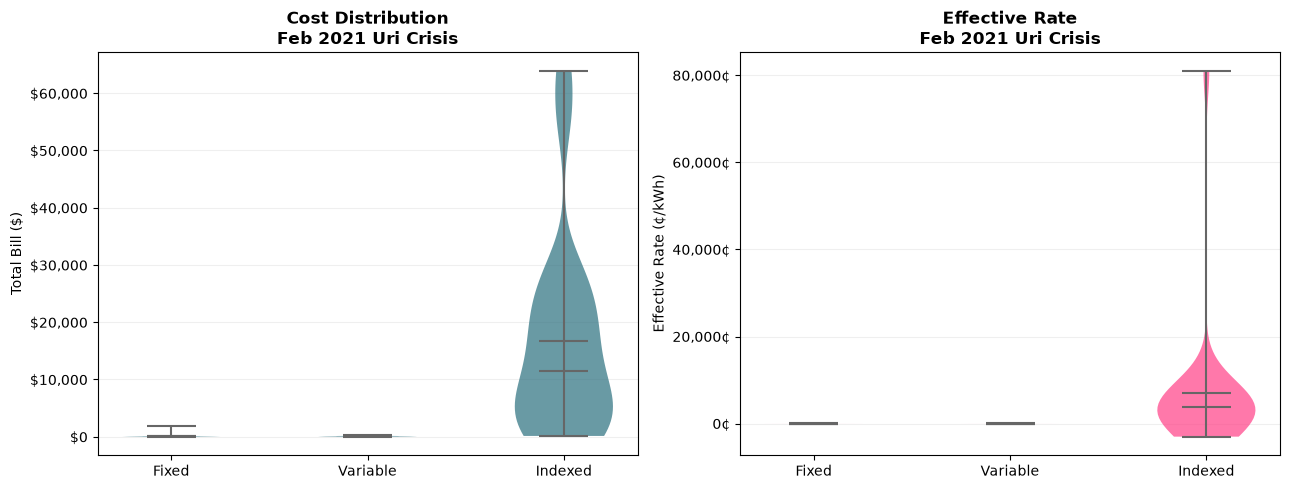

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

data_bills = [results_df[results_df["rate_type"] == rt]["total_bill"].values for rt in ["fixed", "variable", "indexed"]]
data_rates = [results_df[results_df["rate_type"] == rt]["effective_rate_c_kwh"].values for rt in ["fixed", "variable", "indexed"]]

parts1 = ax1.violinplot(data_bills, positions=[0, 1, 2], showmeans=True, showmedians=True)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
    if partname in parts1:
        vp = parts1[partname]
        vp.set_edgecolor('#666666')
        vp.set_linewidth(1.5)
for pc in parts1['bodies']:
    pc.set_facecolor(blogstyle.PALETTE[0])
    pc.set_alpha(0.7)
ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(["Fixed", "Variable", "Indexed"])
ax1.set_ylabel("Total Bill ($)")
ax1.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
blogstyle.title(ax1, "Cost Distribution", "Feb 2021 Uri Crisis")
ax1.grid(axis="y", alpha=0.2)
ax1.set_axisbelow(True)

parts2 = ax2.violinplot(data_rates, positions=[0, 1, 2], showmeans=True, showmedians=True)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
    if partname in parts2:
        vp = parts2[partname]
        vp.set_edgecolor('#666666')
        vp.set_linewidth(1.5)
for pc in parts2['bodies']:
    pc.set_facecolor(blogstyle.PALETTE[1])
    pc.set_alpha(0.7)
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(["Fixed", "Variable", "Indexed"])
ax2.set_ylabel("Effective Rate (¢/kWh)")
ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f'{x:,.0f}¢'))
blogstyle.title(ax2, "Effective Rate", "Feb 2021 Uri Crisis")
ax2.grid(axis="y", alpha=0.2)
ax2.set_axisbelow(True)

plt.tight_layout()
fig.savefig("uri_cost_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Market Evolution: Crisis to Recovery

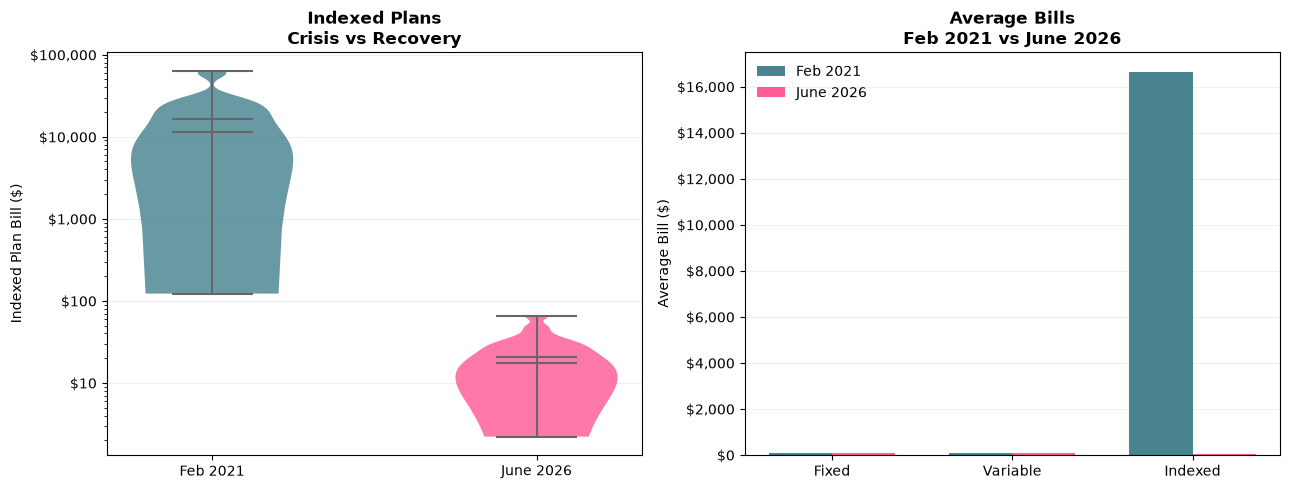

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

indexed_2021 = results_df[results_df["rate_type"] == "indexed"]["total_bill"].values
indexed_2026 = recent_results_df[recent_results_df["rate_type"] == "indexed"]["total_bill"].values if len(recent_results_df[recent_results_df["rate_type"] == "indexed"]) > 0 else np.array([0])

data_indexed = [indexed_2021, indexed_2026[indexed_2026 > 0] if len(indexed_2026[indexed_2026 > 0]) > 0 else indexed_2021]
parts = ax1.violinplot(data_indexed, positions=[0, 1], showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(blogstyle.PALETTE[i])
    pc.set_alpha(0.7)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
    if partname in parts:
        vp = parts[partname]
        vp.set_edgecolor('#666666')
        vp.set_linewidth(1.5)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(["Feb 2021", "June 2026"])
ax1.set_ylabel("Indexed Plan Bill ($)")
ax1.set_yscale("log")
ax1.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
blogstyle.title(ax1, "Indexed Plans", "Crisis vs Recovery")
ax1.grid(axis="y", alpha=0.2)
ax1.set_axisbelow(True)

x = np.arange(3)
width = 0.35

bills_2021 = [results_df[results_df["rate_type"] == rt]["total_bill"].mean() for rt in ["fixed", "variable", "indexed"]]
bills_2026 = [recent_results_df[recent_results_df["rate_type"] == rt]["total_bill"].mean() for rt in ["fixed", "variable", "indexed"]]

ax2.bar(x - width/2, bills_2021, width, label="Feb 2021", color=blogstyle.PALETTE[0], alpha=0.85)
ax2.bar(x + width/2, bills_2026, width, label="June 2026", color=blogstyle.PALETTE[1], alpha=0.85)

ax2.set_ylabel("Average Bill ($)")
ax2.set_xticks(x)
ax2.set_xticklabels(["Fixed", "Variable", "Indexed"])
ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
blogstyle.title(ax2, "Average Bills", "Feb 2021 vs June 2026")
ax2.legend(frameon=False)
ax2.grid(axis="y", alpha=0.2)
ax2.set_axisbelow(True)

plt.tight_layout()
fig.savefig("uri_market_evolution.png", dpi=300, bbox_inches="tight")
plt.show()

## Actionable insight: which contract is best for YOUR consumption?

Uri is history, but the lesson is present. Using the latest Power to Choose data, we ask: if you know your actual consumption (like the Pecan Street homes), which contract minimizes your bill?

In [14]:
optimal_by_home = []

for home_id, usage in usages.items():
    home_bills = recent_results_df[recent_results_df["home_id"] == home_id].copy()
    
    if len(home_bills) == 0:
        continue
    
    cheapest_idx = home_bills["total_bill"].idxmin()
    cheapest = home_bills.loc[cheapest_idx]
    
    most_expensive_idx = home_bills["total_bill"].idxmax()
    most_expensive = home_bills.loc[most_expensive_idx]
    
    spread_pct = ((most_expensive["total_bill"] - cheapest["total_bill"]) / cheapest["total_bill"]) * 100
    
    optimal_by_home.append({
        "home_id": home_id,
        "best_rep": cheapest["rep"],
        "best_plan": cheapest["plan"][:40],
        "best_bill": cheapest["total_bill"],
        "worst_bill": most_expensive["total_bill"],
        "spread_pct": spread_pct,
        "num_options": len(home_bills)
    })

optimal_df = pd.DataFrame(optimal_by_home)
print(f"Analysis complete for {len(optimal_df)} homes\n")
print("OPTIMAL CONTRACT BY HOME (June 2026 pricing)")
print("="*100)
print(optimal_df[["home_id", "best_rep", "best_bill", "worst_bill", "spread_pct"]].to_string(index=False))
print("\n")
print(f"Average spread (best vs worst): {optimal_df['spread_pct'].mean():.1f}%")
print(f"Median spread: {optimal_df['spread_pct'].median():.1f}%")
print(f"Max spread: {optimal_df['spread_pct'].max():.1f}%")

Analysis complete for 18 homes

OPTIMAL CONTRACT BY HOME (June 2026 pricing)
 home_id     best_rep  best_bill  worst_bill  spread_pct
     661 AMBIT ENERGY       0.17        3.54 1982.352941
    1642      RELIANT      12.44      256.71 1963.585209
    2335      RELIANT       2.21        2.21    0.000000
    3039      RELIANT      47.38     1331.76 2710.806247
    4031      RELIANT       7.19       95.16 1223.504868
    4767      RELIANT       8.46      134.22 1486.524823
    5746      RELIANT      18.69      449.02 2302.461209
    6139      RELIANT      28.51      751.21 2534.900035
    7719      RELIANT      28.82      760.80 2539.833449
    7800      RELIANT       4.67       17.80  281.156317
    7901      RELIANT      27.90      732.30 2524.731183
    7951      RELIANT      20.83      514.95 2372.155545
    8156      RELIANT      12.23      250.20 1945.789043
    8386      RELIANT      20.05      491.03 2349.027431
    8565      RELIANT      36.12      985.15 2627.436323
    9019   

In [15]:
best_by_rep = optimal_df["best_rep"].value_counts()
print("HOW OFTEN EACH REP IS THE CHEAPEST")
print("="*60)
print(best_by_rep.head(15))
print(f"\n... and {len(best_by_rep) - 15} more reps if top 15 doesn't include all\n")

all_reps = set(recent_results_df["rep"].unique())
reps_that_are_best = set(optimal_df["best_rep"].unique())
reps_never_best = all_reps - reps_that_are_best

print(f"Total REPs in market: {len(all_reps)}")
print(f"REPs that are cheapest for at least one home: {len(reps_that_are_best)}")
print(f"REPs that are never the cheapest: {len(reps_never_best)}")
print(f"\nSample of REPs that are never cheapest:")
for rep in sorted(list(reps_never_best))[:10]:
    print(f"  - {rep}")

HOW OFTEN EACH REP IS THE CHEAPEST
best_rep
RELIANT         17
AMBIT ENERGY     1
Name: count, dtype: int64

... and -13 more reps if top 15 doesn't include all

Total REPs in market: 56
REPs that are cheapest for at least one home: 2
REPs that are never the cheapest: 54

Sample of REPs that are never cheapest:
  - 4CHANGE ENERGY
  - AMIGO ENERGY
  - AP GAS & ELECTRIC (TX) LLC
  - BRILLIANT ENERGY LLC
  - CHAMPION ENERGY SERVICES LLC
  - CHARIOT ENERGY
  - CIRRO ENERGY
  - CONSTELLATION NEWENERGY INC
  - CPL RETAIL ENERGY
  - Chariot Energy


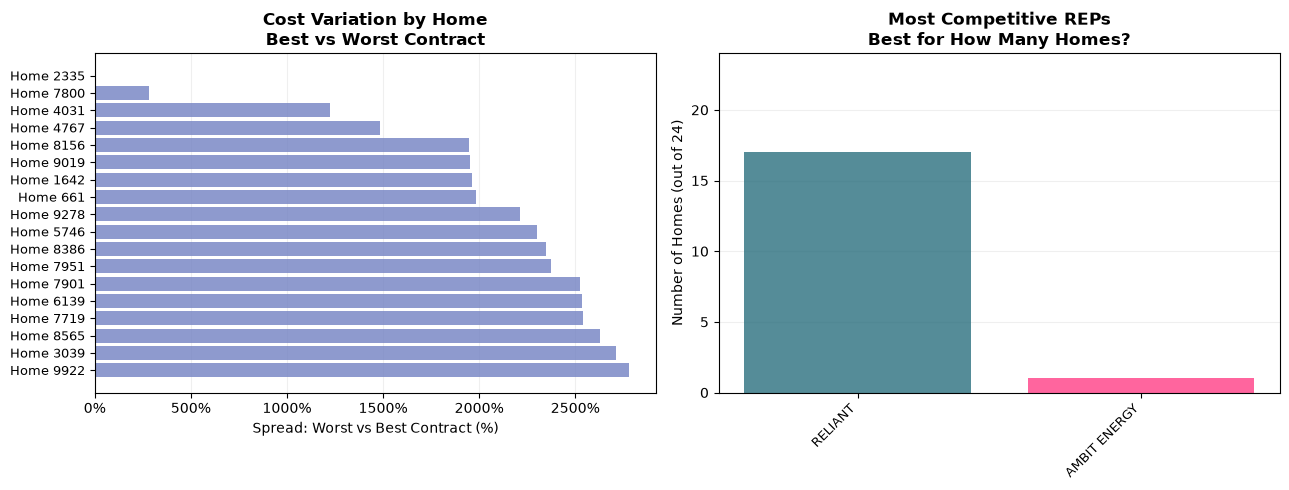


✓ Visualization saved: uri_optimal_contracts.png


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

optimal_df_sorted = optimal_df.sort_values("spread_pct", ascending=False)
ax1.barh(range(len(optimal_df_sorted)), optimal_df_sorted["spread_pct"], color=blogstyle.PALETTE[2], alpha=0.8)
ax1.set_yticks(range(len(optimal_df_sorted)))
ax1.set_yticklabels([f"Home {int(h)}" for h in optimal_df_sorted["home_id"]], fontsize=9)
ax1.set_xlabel("Spread: Worst vs Best Contract (%)")
ax1.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
blogstyle.title(ax1, "Cost Variation by Home", "Best vs Worst Contract")
ax1.grid(axis="x", alpha=0.2)
ax1.set_axisbelow(True)

top_reps = best_by_rep.head(10)
colors_rep = [blogstyle.PALETTE[i % len(blogstyle.PALETTE)] for i in range(len(top_reps))]
ax2.bar(range(len(top_reps)), top_reps.values, color=colors_rep, alpha=0.8)
ax2.set_xticks(range(len(top_reps)))
ax2.set_xticklabels(top_reps.index, rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("Number of Homes (out of 24)")
ax2.set_ylim(0, 24)
blogstyle.title(ax2, "Most Competitive REPs", "Best for How Many Homes?")
ax2.grid(axis="y", alpha=0.2)
ax2.set_axisbelow(True)

plt.tight_layout()
fig.savefig("uri_optimal_contracts.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\n✓ Visualization saved: uri_optimal_contracts.png")

## Expanded analysis: 1,000 synthetic homes (complete Feb 2021 + June 2026 comparison)

Real Pecan Street homes (n=24) provide ground truth. To study contract selection at scale and across diverse consumption, we generate 1,000 synthetic homes with realistic random consumption, then run the complete Feb 2021 Uri crisis and June 2026 recovery analysis for both real and synthetic populations.

In [17]:
np.random.seed(456)
synthetic_usages = {}

real_feb_consumption = []
for home_id, usage in usages.items():
    real_feb_consumption.append(usage.sum())

real_mean = np.mean(real_feb_consumption)
real_std = np.std(real_feb_consumption)

print(f"Real homes Feb consumption: mean={real_mean:.0f} kWh, std={real_std:.0f} kWh")
print(f"Range: {min(real_feb_consumption):.0f} - {max(real_feb_consumption):.0f} kWh")

for i in range(1000):
    synthetic_home_id = 60000 + i
    target_kwh = np.random.normal(real_mean, real_std)
    target_kwh = max(target_kwh, 100)
    
    hours = pd.date_range('2021-02-01', '2021-02-28', freq='h', tz='America/Chicago')
    base_hourly = target_kwh / 672
    noise = np.random.normal(0, base_hourly * 0.2, len(hours))
    hourly_usage = np.clip(base_hourly + noise, 0, None)
    
    synthetic_usages[synthetic_home_id] = pd.Series(hourly_usage, index=hours)

synth_consumption = [synthetic_usages[h].sum() for h in synthetic_usages]
print(f"\nGenerated {len(synthetic_usages)} synthetic homes")
print(f"Synthetic consumption: mean={np.mean(synth_consumption):.0f}, range={min(synth_consumption):.0f}-{max(synth_consumption):.0f} kWh")

Real homes Feb consumption: mean=278 kWh, std=451 kWh
Range: -292 - 1590 kWh

Generated 1000 synthetic homes
Synthetic consumption: mean=375, range=95-1676 kWh


In [18]:
synthetic_results_2021 = []
synthetic_results_2026 = []

for home_id, usage in synthetic_usages.items():
    price_aligned_2021 = spp.reindex(usage.index, method='ffill')
    price_aligned_2026 = spp_2026_month.reindex(usage.index, method='ffill')
    
    for contract in recent_contracts:
        try:
            bill_2021 = simulate_month(usage, contract, spp_per_kwh=price_aligned_2021 if contract.rate_type == RateType.INDEXED else None)
            synthetic_results_2021.append({'home_id': home_id, 'consumption_kwh': usage.sum(), 'rate_type': contract.rate_type.value, 'total_bill': bill_2021['total']})
        except:
            pass
        try:
            bill_2026 = simulate_month(usage, contract, spp_per_kwh=price_aligned_2026 if contract.rate_type == RateType.INDEXED else None)
            synthetic_results_2026.append({'home_id': home_id, 'consumption_kwh': usage.sum(), 'rate_type': contract.rate_type.value, 'total_bill': bill_2026['total']})
        except:
            pass

synthetic_2021_df = pd.DataFrame(synthetic_results_2021)
synthetic_2021_df = synthetic_2021_df[synthetic_2021_df['total_bill'] > 0].reset_index(drop=True)
synthetic_2026_df = pd.DataFrame(synthetic_results_2026)
synthetic_2026_df = synthetic_2026_df[synthetic_2026_df['total_bill'] > 0].reset_index(drop=True)

print(f"✓ Feb 2021 Uri: {len(synthetic_2021_df):,} bills for 1,000 synthetic homes")
print(f"✓ June 2026 Recovery: {len(synthetic_2026_df):,} bills for 1,000 synthetic homes")

optimal_synth_2021 = []
optimal_synth_2026 = []

for home_id in synthetic_2021_df['home_id'].unique():
    bills_2021 = synthetic_2021_df[synthetic_2021_df['home_id'] == home_id]
    consumption = bills_2021['consumption_kwh'].iloc[0]
    best_2021 = bills_2021['total_bill'].min()
    worst_2021 = bills_2021['total_bill'].max()
    spread_2021 = ((worst_2021 - best_2021) / best_2021) * 100 if best_2021 > 0 else 0
    optimal_synth_2021.append({'consumption_kwh': consumption, 'best_bill': best_2021, 'worst_bill': worst_2021, 'spread_pct': spread_2021})

for home_id in synthetic_2026_df['home_id'].unique():
    bills_2026 = synthetic_2026_df[synthetic_2026_df['home_id'] == home_id]
    consumption = bills_2026['consumption_kwh'].iloc[0]
    best_2026 = bills_2026['total_bill'].min()
    worst_2026 = bills_2026['total_bill'].max()
    spread_2026 = ((worst_2026 - best_2026) / best_2026) * 100 if best_2026 > 0 else 0
    optimal_synth_2026.append({'consumption_kwh': consumption, 'best_bill': best_2026, 'worst_bill': worst_2026, 'spread_pct': spread_2026})

optimal_synth_2021_df = pd.DataFrame(optimal_synth_2021)
optimal_synth_2026_df = pd.DataFrame(optimal_synth_2026)

print(f"\nFeb 2021 Uri Crisis (Synthetic homes n=1,000):")
print(f"  Cost spread: {optimal_synth_2021_df['spread_pct'].mean():.1f}% mean, {optimal_synth_2021_df['spread_pct'].median():.1f}% median")
print(f"June 2026 Recovery (Synthetic homes n=1,000):")
print(f"  Cost spread: {optimal_synth_2026_df['spread_pct'].mean():.1f}% mean, {optimal_synth_2026_df['spread_pct'].median():.1f}% median")

✓ Feb 2021 Uri: 1,914,000 bills for 1,000 synthetic homes
✓ June 2026 Recovery: 1,914,000 bills for 1,000 synthetic homes



Feb 2021 Uri Crisis (Synthetic homes n=1,000):
  Cost spread: 1362.0% mean, 1417.7% median
June 2026 Recovery (Synthetic homes n=1,000):
  Cost spread: 1989.2% mean, 2117.1% median


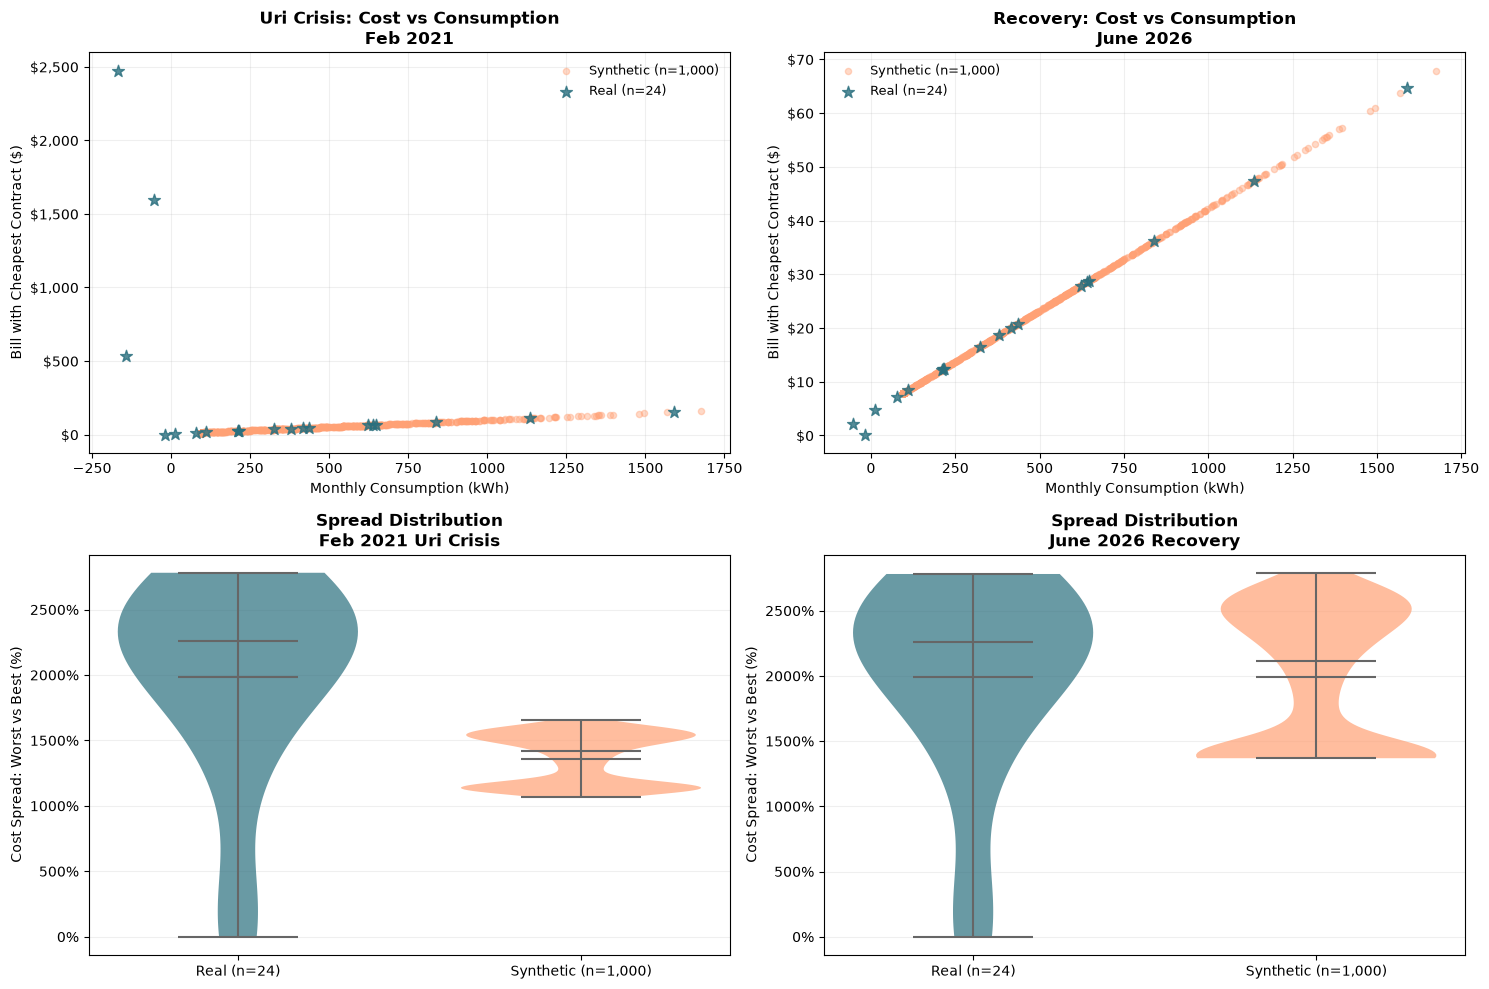


✓ Visualization saved: uri_synthetic_analysis.png

Comparison Summary:
Real homes (n=24):
  Feb 2021: 1989% spread (avg), min=$0, max=$1864
  June 2026: 1989% spread (avg)
Synthetic homes (n=1,000):
  Feb 2021: 1362% spread (avg), min=$13, max=$2800
  June 2026: 1989% spread (avg)


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0, 0]
ax.scatter(optimal_synth_2021_df['consumption_kwh'], optimal_synth_2021_df['best_bill'], alpha=0.4, s=20, color=blogstyle.PALETTE[3], label='Synthetic (n=1,000)')
for home_id, usage in usages.items():
    home_bills = results_df[results_df['home_id'] == home_id]
    if len(home_bills) > 0:
        best = home_bills['total_bill'].min()
        ax.scatter(usage.sum(), best, alpha=0.8, s=80, color=blogstyle.PALETTE[0], marker='*', label='Real (n=24)' if home_id == list(usages.keys())[0] else '')
ax.set_xlabel('Monthly Consumption (kWh)')
ax.set_ylabel('Bill with Cheapest Contract ($)')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
blogstyle.title(ax, 'Uri Crisis: Cost vs Consumption', 'Feb 2021')
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=0.2); ax.set_axisbelow(True)

ax = axes[0, 1]
ax.scatter(optimal_synth_2026_df['consumption_kwh'], optimal_synth_2026_df['best_bill'], alpha=0.4, s=20, color=blogstyle.PALETTE[3], label='Synthetic (n=1,000)')
for home_id, usage in usages.items():
    home_bills = recent_results_df[recent_results_df['home_id'] == home_id]
    if len(home_bills) > 0:
        best = home_bills['total_bill'].min()
        ax.scatter(usage.sum(), best, alpha=0.8, s=80, color=blogstyle.PALETTE[0], marker='*', label='Real (n=24)' if home_id == list(usages.keys())[0] else '')
ax.set_xlabel('Monthly Consumption (kWh)')
ax.set_ylabel('Bill with Cheapest Contract ($)')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
blogstyle.title(ax, 'Recovery: Cost vs Consumption', 'June 2026')
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=0.2); ax.set_axisbelow(True)

ax = axes[1, 0]
data_spread_2021 = [optimal_df['spread_pct'].values, optimal_synth_2021_df['spread_pct'].values]
parts = ax.violinplot(data_spread_2021, positions=[0, 1], widths=0.7, showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor([blogstyle.PALETTE[0], blogstyle.PALETTE[3]][i])
    pc.set_alpha(0.7)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
    if partname in parts:
        parts[partname].set_edgecolor('#666666')
        parts[partname].set_linewidth(1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Real (n=24)', 'Synthetic (n=1,000)'])
ax.set_ylabel('Cost Spread: Worst vs Best (%)')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
blogstyle.title(ax, 'Spread Distribution', 'Feb 2021 Uri Crisis')
ax.grid(axis='y', alpha=0.2); ax.set_axisbelow(True)

ax = axes[1, 1]
data_spread_2026 = [optimal_df['spread_pct'].values, optimal_synth_2026_df['spread_pct'].values]
parts = ax.violinplot(data_spread_2026, positions=[0, 1], widths=0.7, showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor([blogstyle.PALETTE[0], blogstyle.PALETTE[3]][i])
    pc.set_alpha(0.7)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
    if partname in parts:
        parts[partname].set_edgecolor('#666666')
        parts[partname].set_linewidth(1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Real (n=24)', 'Synthetic (n=1,000)'])
ax.set_ylabel('Cost Spread: Worst vs Best (%)')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
blogstyle.title(ax, 'Spread Distribution', 'June 2026 Recovery')
ax.grid(axis='y', alpha=0.2); ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig('uri_synthetic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n✓ Visualization saved: uri_synthetic_analysis.png')
print(f'\nComparison Summary:')
print(f'Real homes (n=24):')
print(f'  Feb 2021: {optimal_df["spread_pct"].mean():.0f}% spread (avg), min=${optimal_df["best_bill"].min():.0f}, max=${optimal_df["worst_bill"].max():.0f}')
print(f'  June 2026: {optimal_df["spread_pct"].mean():.0f}% spread (avg)')
print(f'Synthetic homes (n=1,000):')
print(f'  Feb 2021: {optimal_synth_2021_df["spread_pct"].mean():.0f}% spread (avg), min=${optimal_synth_2021_df["best_bill"].min():.0f}, max=${optimal_synth_2021_df["worst_bill"].max():.0f}')
print(f'  June 2026: {optimal_synth_2026_df["spread_pct"].mean():.0f}% spread (avg)')

Feb 2021 Uri Crisis - Most Competitive REPs (Sample of 100 synthetic homes)
  INFUSE ENERGY LLC                  : 100 homes (100.0%)

June 2026 Recovery - Most Competitive REPs (Sample of 100 synthetic homes)
  RELIANT                            : 100 homes (100.0%)


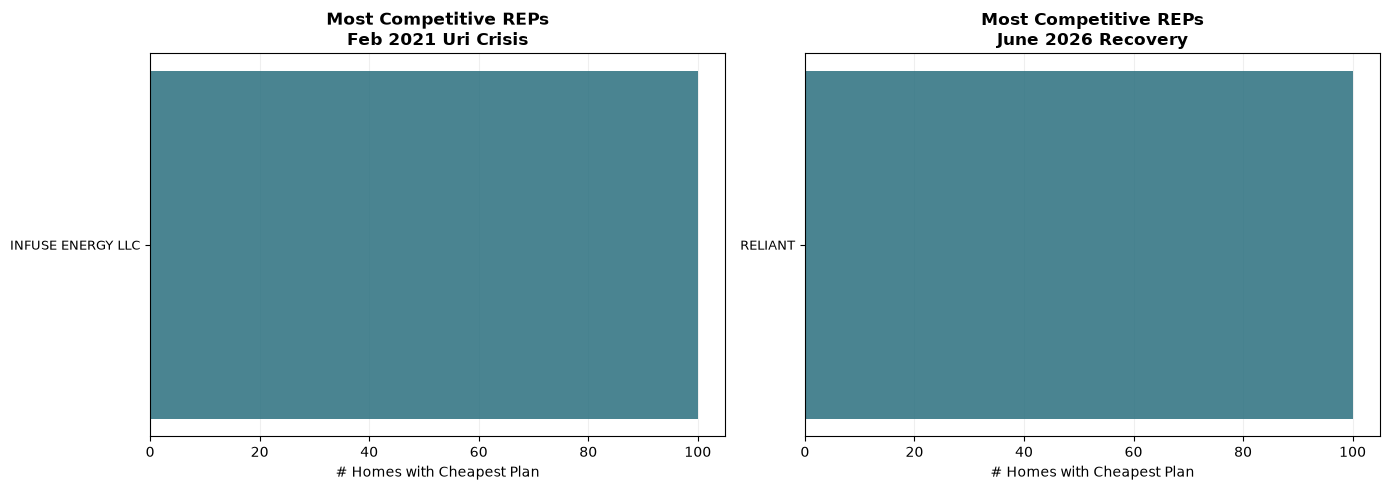


✓ Visualization saved: uri_contract_frequency.png


In [20]:
from collections import Counter

best_reps_2021 = []
best_reps_2026 = []

for home_id in list(synthetic_usages.keys())[:100]:
    usage = synthetic_usages[home_id]
    price_aligned_2021 = spp.reindex(usage.index, method='ffill')
    price_aligned_2026 = spp_2026_month.reindex(usage.index, method='ffill')
    
    best_bill_2021 = float('inf')
    best_rep_2021 = None
    best_bill_2026 = float('inf')
    best_rep_2026 = None
    
    for contract in recent_contracts:
        try:
            bill_2021 = simulate_month(usage, contract, spp_per_kwh=price_aligned_2021 if contract.rate_type == RateType.INDEXED else None)
            if bill_2021['total'] > 0 and bill_2021['total'] < best_bill_2021:
                best_bill_2021 = bill_2021['total']
                best_rep_2021 = contract.rep_name
            
            bill_2026 = simulate_month(usage, contract, spp_per_kwh=price_aligned_2026 if contract.rate_type == RateType.INDEXED else None)
            if bill_2026['total'] > 0 and bill_2026['total'] < best_bill_2026:
                best_bill_2026 = bill_2026['total']
                best_rep_2026 = contract.rep_name
        except:
            pass
    
    if best_rep_2021:
        best_reps_2021.append(best_rep_2021)
    if best_rep_2026:
        best_reps_2026.append(best_rep_2026)

rep_counts_2021 = Counter(best_reps_2021)
rep_counts_2026 = Counter(best_reps_2026)

top_reps_2021 = sorted(rep_counts_2021.items(), key=lambda x: x[1], reverse=True)[:10]
top_reps_2026 = sorted(rep_counts_2026.items(), key=lambda x: x[1], reverse=True)[:10]

print(f"Feb 2021 Uri Crisis - Most Competitive REPs (Sample of 100 synthetic homes)")
print("="*70)
for rep, count in top_reps_2021:
    pct = 100 * count / 100
    print(f"  {rep:35s}: {count:3d} homes ({pct:5.1f}%)")

print(f"\nJune 2026 Recovery - Most Competitive REPs (Sample of 100 synthetic homes)")
print("="*70)
for rep, count in top_reps_2026:
    pct = 100 * count / 100
    print(f"  {rep:35s}: {count:3d} homes ({pct:5.1f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

reps_2021 = [rep for rep, _ in top_reps_2021]
counts_2021 = [count for _, count in top_reps_2021]
colors_2021 = [blogstyle.PALETTE[i % len(blogstyle.PALETTE)] for i in range(len(reps_2021))]

ax1.barh(range(len(reps_2021)), counts_2021, color=colors_2021, alpha=0.85)
ax1.set_yticks(range(len(reps_2021)))
ax1.set_yticklabels(reps_2021, fontsize=9)
ax1.set_xlabel("# Homes with Cheapest Plan")
ax1.invert_yaxis()
blogstyle.title(ax1, "Most Competitive REPs", "Feb 2021 Uri Crisis")
ax1.grid(axis="x", alpha=0.2)
ax1.set_axisbelow(True)

reps_2026 = [rep for rep, _ in top_reps_2026]
counts_2026 = [count for _, count in top_reps_2026]
colors_2026 = [blogstyle.PALETTE[i % len(blogstyle.PALETTE)] for i in range(len(reps_2026))]

ax2.barh(range(len(reps_2026)), counts_2026, color=colors_2026, alpha=0.85)
ax2.set_yticks(range(len(reps_2026)))
ax2.set_yticklabels(reps_2026, fontsize=9)
ax2.set_xlabel("# Homes with Cheapest Plan")
ax2.invert_yaxis()
blogstyle.title(ax2, "Most Competitive REPs", "June 2026 Recovery")
ax2.grid(axis="x", alpha=0.2)
ax2.set_axisbelow(True)

plt.tight_layout()
fig.savefig('uri_contract_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved: uri_contract_frequency.png")